In [ ]:
import random
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
def binary_bandit(out):
    return int(random.random() < out)

In [ ]:
class Bandit:
    def __init__(self, N):
        self.N = N

    def actions(self):
        return list(range(self.N))

In [ ]:
bandit = Bandit(N=2)

In [ ]:
def e_greedy(bandit, epsilon, iterations, probabilities):
    estimated_values = [0] * bandit.N
    action_counts = [0] * bandit.N
    reward = 0
    reward_history = []
    average_rewards = [0]

    for step in range(1, iterations):
        if random.random() > epsilon:
            selected_action = estimated_values.index(max(estimated_values))
        else:
            selected_action = random.choice(bandit.actions())

        reward = binary_bandit(probabilities[selected_action])
        reward_history.append(reward)
        action_counts[selected_action] += 1
        estimated_values[selected_action] += (reward - estimated_values[selected_action]) / action_counts[selected_action]
        average_rewards.append(average_rewards[step - 1] + (reward - average_rewards[step - 1]) / step)

    return estimated_values, average_rewards, reward_history

Text(0.5, 1.0, 'average rewards acculumated over time')

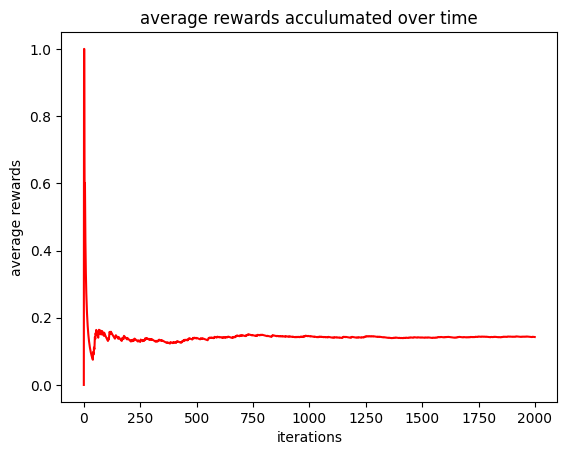

In [ ]:
p=[0.1, 0.15]
Q, R_avg, R = e_greedy(bandit, 0.2, 2000,p)
plt.plot(R_avg, color='red')
plt.xlabel("iterations")
plt.ylabel("average rewards")
plt.title("average rewards acculumated over time")

Text(0.5, 1.0, 'average rewards acculumated over time')

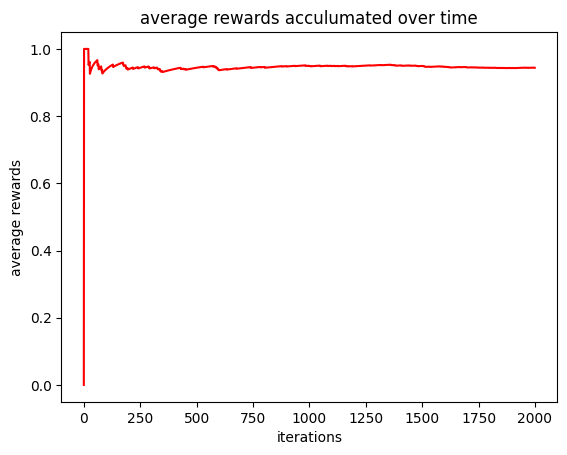

In [ ]:
p=[0.95, 0.9]
Q, R_avg_2, R = e_greedy(bandit, 0.2, 2000,p)
plt.plot(R_avg_2,color='red');
plt.xlabel("iterations")
plt.ylabel("average rewards")
plt.title("average rewards acculumated over time")

In [ ]:
class Bandit(object):
    def __init__(self, N):
        self.N = N
        expRewards = np.array([10]*self.N)
        self.expRewards = expRewards

    def actions(self):
        result = []
        for i in range(0,self.N):
            result.append(i)
            return result

    def increment_reward(self):
        incArray = np.random.normal(0,0.01,10)
        self.expRewards = self.expRewards + incArray

    def reward(self, action):
        result = []
        n = random.gauss(0,1)
        result = self.expRewards[action]
        return result

In [ ]:
def e_greedy_3(bandit, epsilon, max_steps):
    # Initialization
    estimated_values = [0] * bandit.N
    action_counts = [0] * bandit.N
    average_rewards = [0]
    total_reward = 0
    reward_history = []
    current_reward = 0

    # Incremental Implementation
    for step in range(1, max_steps + 1):
        if random.random() < epsilon:
            # Explore
            chosen_action = random.choice(bandit.actions())
        else:
            # Exploit/Greedy
            chosen_action = estimated_values.index(max(estimated_values))

        reward = bandit.reward(chosen_action)
        current_reward = bandit.reward(chosen_action)
        reward_history.append(current_reward)
        bandit.increment_reward()
        total_reward += reward
        average_rewards.append(total_reward / step)

        action_counts[chosen_action] += 1
        estimated_values[chosen_action] += (reward - estimated_values[chosen_action]) / action_counts[chosen_action]

    return estimated_values, average_rewards, reward_history

In [ ]:
myBandit = Bandit(N=10)

Text(0.5, 1.0, 'instantaneous rewards given by environment')

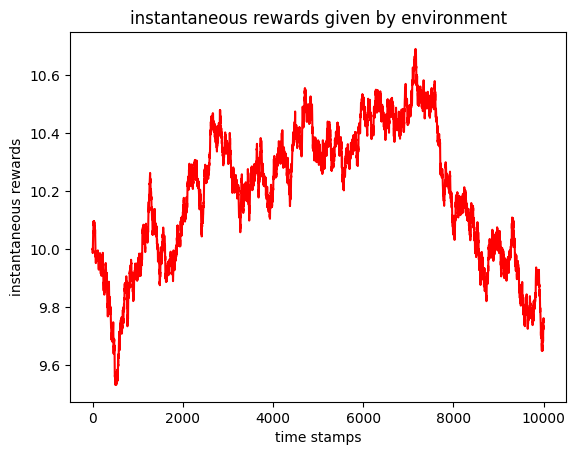

In [ ]:
Q_,r_avg,R = e_greedy_3(myBandit, 0.2, 10000)
plt.plot(R,color='red');
plt.xlabel("time stamps")
plt.ylabel("instantaneous rewards")
plt.title("instantaneous rewards given by environment")

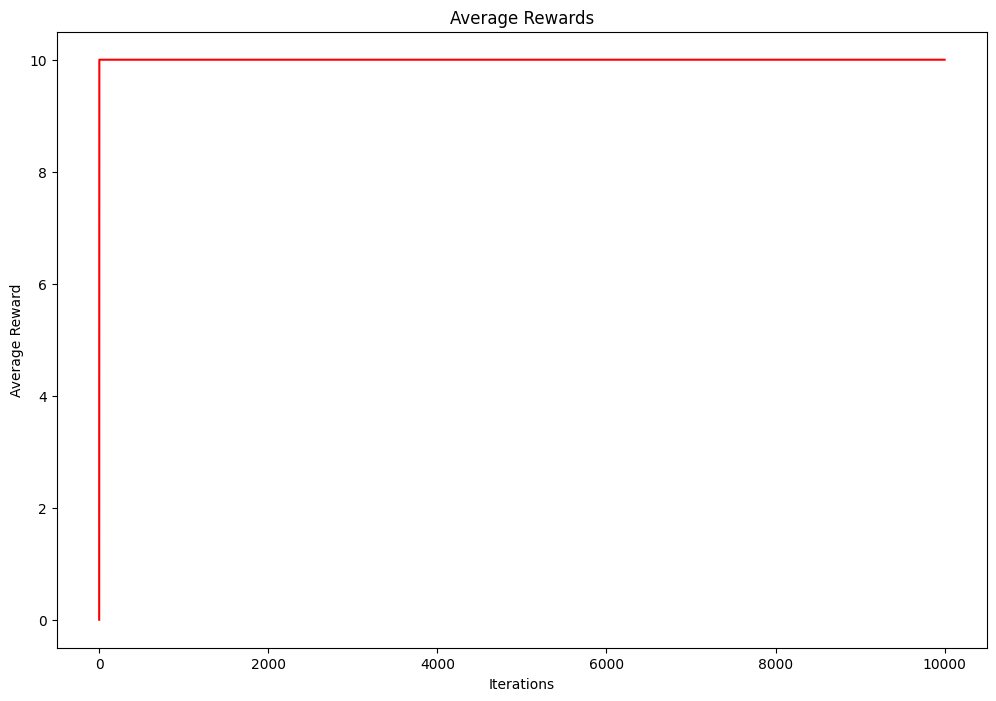

In [ ]:
plt.figure(figsize=(12, 8))
plt.plot(r_avg,color='red')
plt.xlabel("Iterations")
plt.ylabel("Average Reward")
plt.title("Average Rewards")
plt.show()

In [ ]:
def e_greedy2(bandit, epsilon, alpha, iterations):
    # Initialize variables
    estimated_values = [0] * bandit.N
    action_counts = [0] * bandit.N
    average_rewards = [0]
    total_rewards = []

    # Iterative process
    for step in range(1, iterations + 1):
        if random.random() < epsilon:
            # Exploration: Choose a random action
            chosen_action = random.choice(bandit.actions())
        else:
            # Exploitation: Choose the best-known action
            chosen_action = estimated_values.index(max(estimated_values))

        # Get reward for the chosen action
        reward = bandit.reward(chosen_action)
        bandit.increment_reward()  # Simulate non-stationary rewards
        total_rewards.append(reward)

        # Update estimated value using alpha for a weighted update
        action_counts[chosen_action] += 1
        estimated_values[chosen_action] += alpha * (reward - estimated_values[chosen_action])

        # Update average reward
        average_rewards.append(average_rewards[-1] + (reward - average_rewards[-1]) / step)

    return estimated_values, average_rewards, total_rewards

Text(0.5, 1.0, 'average rewards')

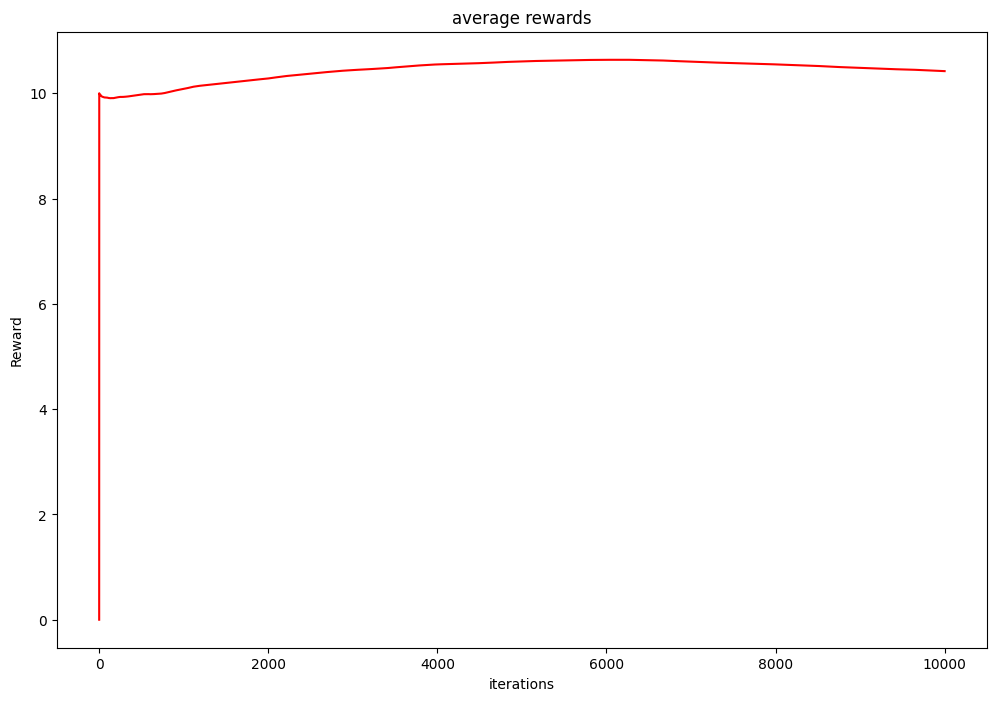

In [ ]:
myBandit = Bandit(N=10)
Q,R_avg, R = e_greedy2(myBandit, 0.4, 0.1, 10000)
plt.figure(figsize=(12,8))
plt.plot(R_avg,color='red');
plt.xlabel("iterations")
plt.ylabel("Reward")
plt.title("average rewards")

Text(0, 0.5, 'rewards')

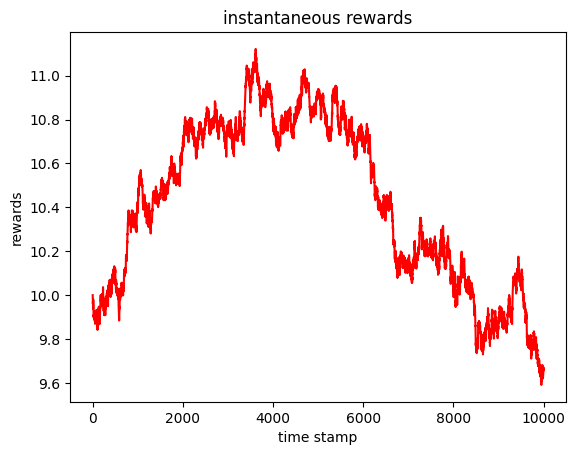

In [ ]:
plt.plot(R,color='red');
plt.title("instantaneous rewards")
plt.xlabel("time stamp")
plt.ylabel("rewards")